<a href="https://colab.research.google.com/github/anajulidorio/classificacao-eventos-climaticos/blob/main/Notebooks/Pr%C3%A9_processamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Carregar Dados
df = pd.read_csv('weatherAUS_limpo.csv').drop_duplicates().reset_index(drop=True)

# 2. Mapeamento de Categóricas e Limpeza
if 'RainToday' in df.columns:
    df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
if 'RainTomorrow' in df.columns:
    df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Remover registros sem a variável alvo de temperatura
df = df.dropna(subset=['MaxTemp']).reset_index(drop=True)

# 3. Tratamento de Nulos por Imputação da Mediana
colunas_categoricas = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in colunas_categoricas:
    if col in df.columns:
        df[col] = df[col].fillna('Não Informado').astype(str)

colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in colunas_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# 4. Definição do Alvo (MaxTemp) e Features (X)
# ATENÇÃO: Mantemos Temp3pm, Temp9am e MinTemp em X!
y_reg = df['MaxTemp']
features_para_remover = ['Date', 'Location', 'MaxTemp', 'RainTomorrow']
X = df.drop(columns=[col for col in features_para_remover if col in df.columns])

# 5. Split dos Dados (70% Treino, 15% Validação, 15% Teste)
X_train, X_temp, y_train_reg, y_temp_reg = train_test_split(
    X, y_reg, test_size=0.30, random_state=42
)
X_val, X_test, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_reg, test_size=0.50, random_state=42
)

# 6. Processamento de Scaler e OneHot
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("✅ Pré-processamento ajustado com sucesso!")

✅ Pré-processamento ajustado com sucesso!



--- TREINANDO MODELOS DE CLASSIFICAÇÃO ---

=== TABELA DE MÉTRICAS - CLASSIFICAÇÃO ===


,Modelo,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro)
0,Modelo A (Regressão Logística),0.8438,0.7920,0.7159,0.7419
1,Modelo B (KNN - K-Nearest Neighbors),0.8406,0.7888,0.7063,0.7332


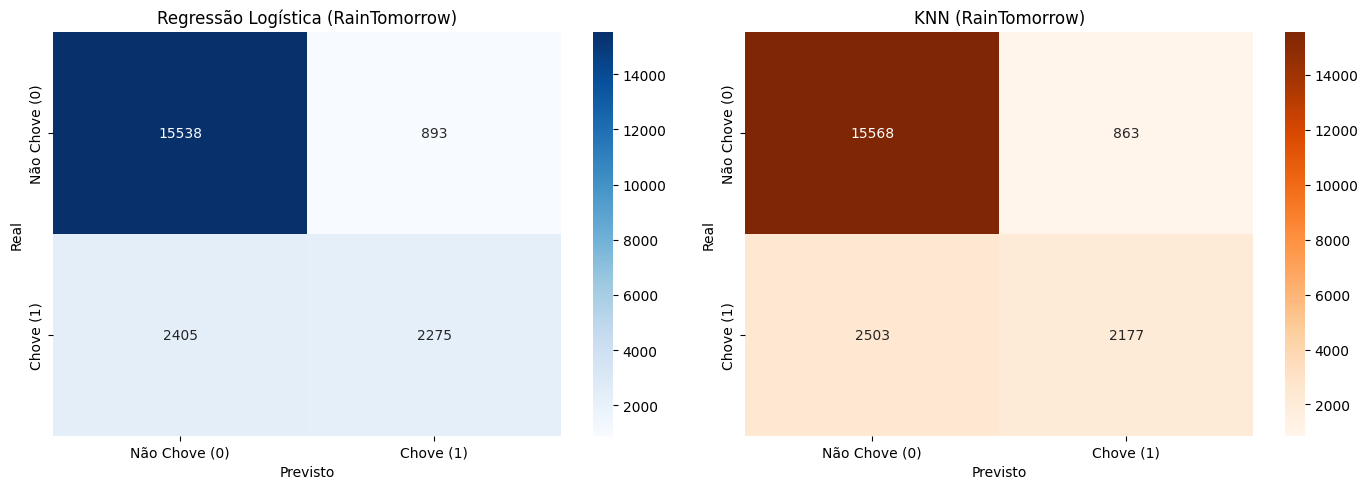

In [5]:
# ==============================================================================
# PARTE 1: ABORDAGEM DE CLASSIFICAÇÃO (Previsão de Chuva Amanhã: RainTomorrow)
# Modelos Utilizados: Regressão Logística e KNN (K-Nearest Neighbors)
# ==============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

print("\n--- TREINANDO MODELOS DE CLASSIFICAÇÃO ---")

# MODELO A: Regressão Logística
param_grid_lr = {
    'C': [0.1, 1.0, 10.0],
    'max_iter': [500]
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='f1_macro')
grid_lr.fit(X_train_prep, y_train_cls)
modelo_A_cls = grid_lr.best_estimator_

# MODELO B: K-Nearest Neighbors (KNN)
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1_macro')
grid_knn.fit(X_train_prep, y_train_cls)
modelo_B_cls = grid_knn.best_estimator_

# Avaliação no Teste
y_pred_lr = modelo_A_cls.predict(X_test_prep)
y_pred_knn = modelo_B_cls.predict(X_test_prep)

def metricas_cls(y_true, y_pred, nome):
    return {
        'Modelo': nome,
        'Acurácia': f"{accuracy_score(y_true, y_pred):.4f}",
        'Precisão (Macro)': f"{precision_score(y_true, y_pred, average='macro'):.4f}",
        'Recall (Macro)': f"{recall_score(y_true, y_pred, average='macro'):.4f}",
        'F1-Score (Macro)': f"{f1_score(y_true, y_pred, average='macro'):.4f}"
    }

df_res_cls = pd.DataFrame([
    metricas_cls(y_test_cls, y_pred_lr, "Modelo A (Regressão Logística)"),
    metricas_cls(y_test_cls, y_pred_knn, "Modelo B (KNN - K-Nearest Neighbors)")
])

print("\n=== TABELA DE MÉTRICAS - CLASSIFICAÇÃO ===")
display(df_res_cls)

# Matrizes de Confusão com Rótulos de Reais e Previstos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = ['Não Chove (0)', 'Chove (1)']

# Regressão Logística
sns.heatmap(
    confusion_matrix(y_test_cls, y_pred_lr),
    annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=classes, yticklabels=classes
)
axes[0].set_title('Regressão Logística (RainTomorrow)')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# KNN
sns.heatmap(
    confusion_matrix(y_test_cls, y_pred_knn),
    annot=True, fmt='d', cmap='Oranges', ax=axes[1],
    xticklabels=classes, yticklabels=classes
)
axes[1].set_title('KNN (RainTomorrow)')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


--- TREINANDO MODELOS DE CLASSIFICAÇÃO ---

=== TABELA DE MÉTRICAS - CLASSIFICAÇÃO ===


,Modelo,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro)
0,Modelo A (Regressão Logística),0.8438,0.7921,0.7160,0.7420
1,Modelo B (KNN - K-Nearest Neighbors),0.8385,0.7832,0.7055,0.7313


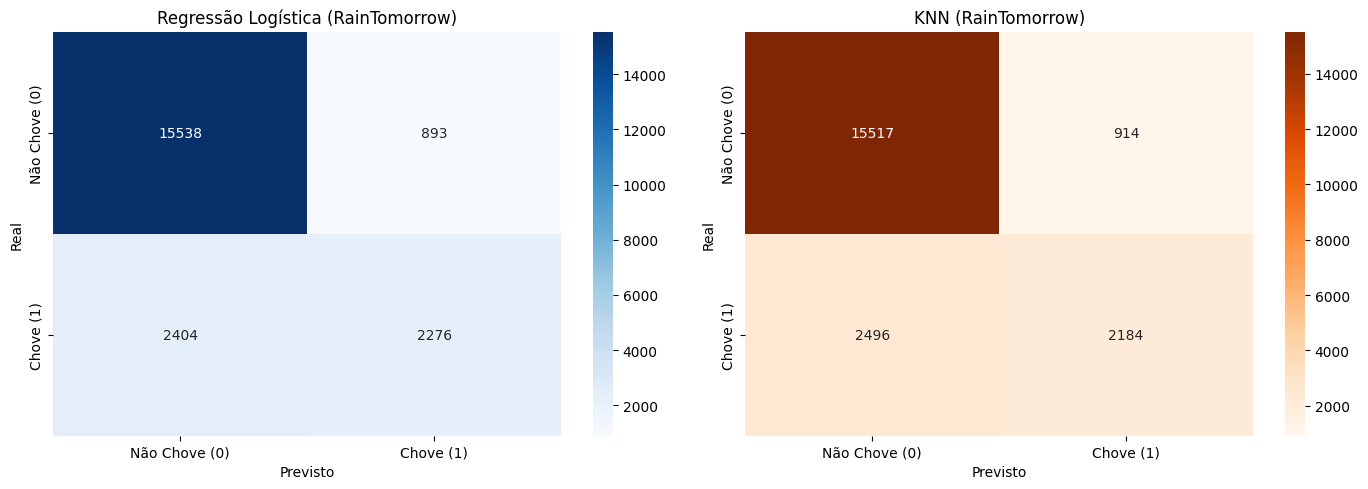

In [4]:
# ==============================================================================
# PARTE 1: ABORDAGEM DE CLASSIFICAÇÃO (Previsão de Chuva Amanhã: RainTomorrow) - OTIMIZADO
# Modelos Utilizados: Regressão Logística e KNN (K-Nearest Neighbors)
# ==============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

print("\n--- TREINANDO MODELOS DE CLASSIFICAÇÃO ---")

# MODELO A: Regressão Logística (n_jobs=-1 para paralelizar)
param_grid_lr = {
    'C': [0.1, 1.0],
    'max_iter': [500]
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
grid_lr.fit(X_train_prep, y_train_cls)
modelo_A_cls = grid_lr.best_estimator_

# MODELO B: K-Nearest Neighbors (KNN com n_jobs=-1 e grade reduzida)
param_grid_knn = {
    'n_neighbors': [5, 7],
    'weights': ['uniform']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
grid_knn.fit(X_train_prep, y_train_cls)
modelo_B_cls = grid_knn.best_estimator_

# Avaliação no Teste
y_pred_lr = modelo_A_cls.predict(X_test_prep)
y_pred_knn = modelo_B_cls.predict(X_test_prep)

def metricas_cls(y_true, y_pred, nome):
    return {
        'Modelo': nome,
        'Acurácia': f"{accuracy_score(y_true, y_pred):.4f}",
        'Precisão (Macro)': f"{precision_score(y_true, y_pred, average='macro'):.4f}",
        'Recall (Macro)': f"{recall_score(y_true, y_pred, average='macro'):.4f}",
        'F1-Score (Macro)': f"{f1_score(y_true, y_pred, average='macro'):.4f}"
    }

df_res_cls = pd.DataFrame([
    metricas_cls(y_test_cls, y_pred_lr, "Modelo A (Regressão Logística)"),
    metricas_cls(y_test_cls, y_pred_knn, "Modelo B (KNN - K-Nearest Neighbors)")
])

print("\n=== TABELA DE MÉTRICAS - CLASSIFICAÇÃO ===")
display(df_res_cls)

# Matrizes de Confusão com Rótulos de Reais e Previstos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = ['Não Chove (0)', 'Chove (1)']

# Regressão Logística
sns.heatmap(
    confusion_matrix(y_test_cls, y_pred_lr),
    annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=classes, yticklabels=classes
)
axes[0].set_title('Regressão Logística (RainTomorrow)')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# KNN
sns.heatmap(
    confusion_matrix(y_test_cls, y_pred_knn),
    annot=True, fmt='d', cmap='Oranges', ax=axes[1],
    xticklabels=classes, yticklabels=classes
)
axes[1].set_title('KNN (RainTomorrow)')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


--- TREINANDO MODELOS DE REGRESSÃO ---

=== MÉTRICAS - PREVISÃO DE TEMPERATURA MÁXIMA ===


,Modelo,MAE (°C),RMSE (°C),R² Score
0,Regressão Linear,0.9244,1.4787,0.9569
1,KNN Regressor,1.5361,2.0313,0.9187


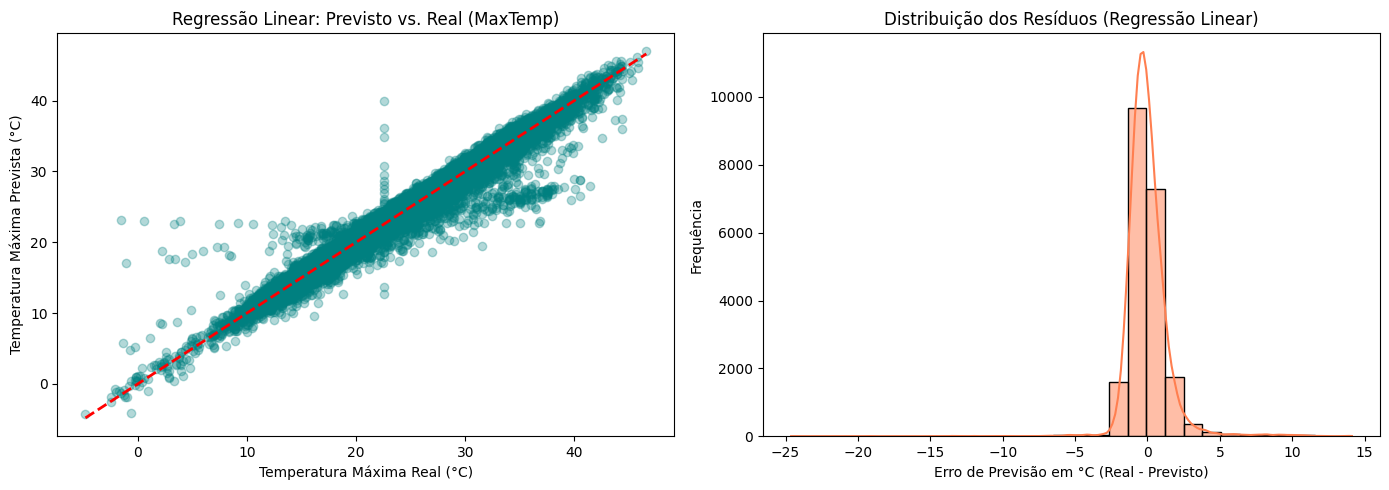

In [11]:
# ==============================================================================
# PARTE 2: REGRESSÃO COM VARIÁVEIS TÉRMICAS PRESERVADAS
# ==============================================================================

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils import resample

print("\n--- TREINANDO MODELOS DE REGRESSÃO ---")

# MODELO A: Regressão Linear
modelo_A_reg = LinearRegression()
modelo_A_reg.fit(X_train_prep, y_train_reg)

# MODELO B: KNN Regressor (Amostra de 20.000 pontos)
X_train_knn, y_train_knn = resample(
    X_train_prep, y_train_reg,
    n_samples=min(20000, X_train_prep.shape[0]),
    random_state=42
)

param_grid_knn = {'n_neighbors': [5, 9], 'weights': ['distance']}
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=3, scoring='r2', n_jobs=-1)
grid_knn.fit(X_train_knn, y_train_knn)
modelo_B_reg = grid_knn.best_estimator_

# Predições
y_pred_lr = modelo_A_reg.predict(X_test_prep)
y_pred_knn = modelo_B_reg.predict(X_test_prep)

# Cálculo das Métricas
def calc_metricas(y_true, y_pred, nome):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'Modelo': nome,
        'MAE (°C)': f"{mean_absolute_error(y_true, y_pred):.4f}",
        'RMSE (°C)': f"{np.sqrt(mse):.4f}",
        'R² Score': f"{r2_score(y_true, y_pred):.4f}"
    }

df_res_temp = pd.DataFrame([
    calc_metricas(y_test_reg, y_pred_lr, "Regressão Linear"),
    calc_metricas(y_test_reg, y_pred_knn, "KNN Regressor")
])

print("\n=== MÉTRICAS - PREVISÃO DE TEMPERATURA MÁXIMA ===")
display(df_res_temp)

# ==============================================================================
# VISUALIZAÇÃO DE DESEMPENHO DA REGRESSÃO (MaxTemp)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Previsto vs Real (Regressão Linear)
axes[0].scatter(y_test_reg, y_pred_lr, alpha=0.3, color='teal')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_title('Regressão Linear: Previsto vs. Real (MaxTemp)')
axes[0].set_xlabel('Temperatura Máxima Real (°C)')
axes[0].set_ylabel('Temperatura Máxima Prevista (°C)')

# Gráfico 2: Distribuição dos Resíduos (Erros de Previsão)
residuos_lr = y_test_reg - y_pred_lr
sns.histplot(residuos_lr, bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribuição dos Resíduos (Regressão Linear)')
axes[1].set_xlabel('Erro de Previsão em °C (Real - Previsto)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()